# **05. 콘텐츠 기반 필터링 실습-TMDB 5000 영화 데이터 세트**

**장르 속성을 이용한 영화 콘텐츠 기반 필터링**
* 특정 영화와 비슷한 특성/속성, 구성 요소 등을 가진 다른 영화 추천
* 영화 간의 유사성을 판단하는 기준이 영화를 구성하는 다양한 콘텐츠를 기반으로 하는 방식

**데이터 로딩 및 가공**

In [31]:
import pandas as pd
import numpy as np
import warnings; warnings.filterwarnings('ignore')

movies = pd.read_csv('/content/tmdb_5000_movies.csv')
print(movies.shape)
movies.head(1)

(4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ""future""}, {""id"": 3386, ""name"": ""sp...",en,Avatar,"In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, ...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289}, {""name"": ""Twentieth Century Fox Film Corporatio...","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}, {""iso_3166_1"": ""GB"", ""name"": ""United ...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,Enter the World of Pandora.,Avatar,7.2,11800


In [32]:
movies_df = movies[['id', 'title', 'genres', 'vote_average', 'vote_count', 'popularity', 'keywords', 'overview']]

* ‘genres’, ‘keywords’ 등과 같은 칼럼을 보면 [{"id"： 28, "name"： "Action"}, {"id"： 12, "name"：
"Adventure"}]와 같이 파이썬 리스트(list) 내부에 여러 개의 딕셔너리(diet)가 있는 형태의 문자열로
표기돼 있음

In [33]:
pd.set_option('max_colwidth', 100)
movies_df[['genres', 'keywords']][:1]

,genres,keywords
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ""future""}, {""id"": 3386, ""name"": ""sp..."


In [34]:
from ast import literal_eval
import numpy as np

def safe_literal_eval(val):
    if isinstance(val, str):
        try:
            return literal_eval(val)
        except (ValueError, SyntaxError):
            return []
    elif val is np.nan:
        return []
    else:
        return []

movies_df['genres'] = movies_df['genres'].apply(safe_literal_eval)
movies_df['keywords'] = movies_df['keywords'].apply(safe_literal_eval)

In [35]:
movies_df['genres'] = movies_df['genres'].apply(lambda x: [y['name'] for y in x])
movies_df['keywords'] = movies_df['keywords'].apply(lambda x: [y['name'] for y in x])
movies_df[['genres', 'keywords']][:1]

,genres,keywords
0,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colony, society, space travel, futuristic, romance, spa..."


**장르 콘텐츠 유사도 측정**
* 문자열로 변환된 genres 칼럼을 Count 기반으로 피처 벡터화 변환
* genres 문자열을 피처 벡터화 행렬로 변환한 데이터 세트로 코사인 유사도를 통해 비교합니다. 이를 위해 데이터 세트의 레크드별로 타 레코드와 장르에서 코사인 유사도 값을 가지는 객체를 생성
* 장르 유사도가 높은 영화 중에 평점이 높은 순으로 영화를 추천

In [36]:
from sklearn.feature_extraction.text import CountVectorizer

movies_df['genres_literal'] = movies_df['genres'].apply(lambda x:(' ').join(x))
count_vect = CountVectorizer(min_df = 1, ngram_range=(1,2))
genre_mat = count_vect.fit_transform(movies_df['genres_literal'])
print(genre_mat.shape)

(4803, 276)


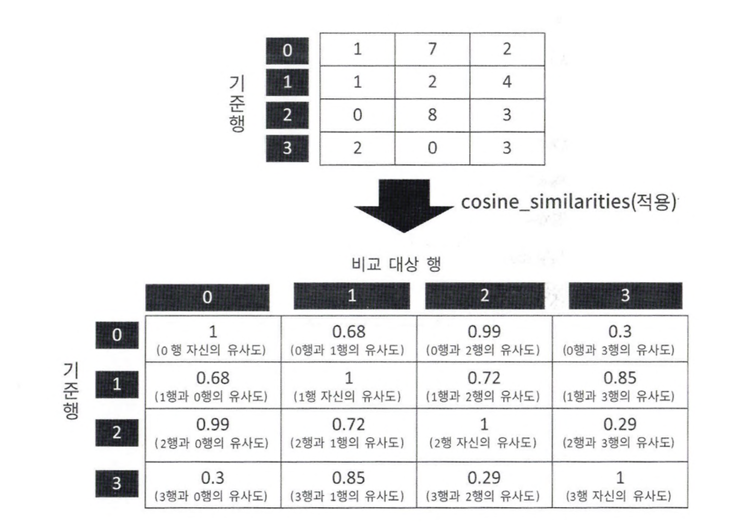

In [37]:
from sklearn.metrics.pairwise import cosine_similarity

genre_sim = cosine_similarity(genre_mat, genre_mat)
print(genre_sim.shape)
print(genre_sim[:2])

(4803, 4803)
[[1.         0.59628479 0.4472136  ... 0.         0.         0.        ]
 [0.59628479 1.         0.4        ... 0.         0.         0.        ]]


In [38]:
genre_sim_sorted_ind = genre_sim.argsort()[:, ::-1]
print(genre_sim_sorted_ind[:1])

[[   0   46 3494 ... 3331 3333 2031]]


**장르 콘텐츠 필터링을 이용한 영화추천**

In [39]:
def find_sim_movie(df, sorted_ind, title_name, top_n = 10):
  title_movie = df[df['title'] == title_name]

  title_index = title_movie.index.values
  similar_indexes = sorted_ind[title_index, :(top_n)]

  print(similar_indexes)
  similar_indexes = similar_indexes.reshape(-1)

  return df.iloc[similar_indexes]

In [40]:
similar_movies = find_sim_movie(movies_df, genre_sim_sorted_ind, 'The Godfather', 10)
similar_movies[['title', 'vote_average']]

[[1881 3378 3866 1370 1464  588 3887 3594 2839  892]]


,title,vote_average
1881,The Shawshank Redemption,8.5
3378,Auto Focus,6.1
3866,City of God,8.1
1370,21,6.5
1464,Black Water Transit,0.0
588,Wall Street: Money Never Sleeps,5.8
3887,Trainspotting,7.8
3594,Spring Breakers,5.0
2839,Rounders,6.9
892,Casino,7.8


In [41]:
movies_df[['title', 'vote_average', 'vote_count']].sort_values('vote_average', ascending=False)[:10]

,title,vote_average,vote_count
4662,Little Big Top,10.0,1
3519,Stiff Upper Lips,10.0,1
4045,"Dancer, Texas Pop. 81",10.0,1
4247,Me You and Five Bucks,10.0,2
3992,Sardaarji,9.5,2
2386,One Man's Hero,9.3,2
1881,The Shawshank Redemption,8.5,8205
2970,There Goes My Baby,8.5,2
3337,The Godfather,8.4,5893
2796,The Prisoner of Zenda,8.4,11


* 왜곡된 평점 데이터를 회피할 수 있도록 평점에 평가 횟수를 반영할 수 있는 새로운 평가 방식이 필요


```
가중평점(Weighted Rating) = (v/(v+m))*R +(m/(v+m))*C
```
* v: 개별 영화에 평점을 투표한 횟수: vote_count
* m: 평점을 부여하기 위한 최소 투표 횟수
* R: 개별 영화에 대한 평균 평점: vote_average
* C: 젼체 영화에 대한 평균 평점



In [42]:
C = movies_df['vote_average'].mean()
m = movies_df['vote_count'].quantile(0.6)
print('C:',  round(C,3), 'm:', round(m,3))

C: 6.092 m: 370.2


In [43]:
percentile = 0.6
m = movies_df['vote_count'].quantile(percentile)
C = movies_df['vote_average'].mean()

def weighted_vote_average(record):
  v = record['vote_count']
  R = record['vote_average']

  return ((v/(v+m))*R) + ((m/(m+v))*C)

movies_df['weighted_vote'] = movies.apply(weighted_vote_average, axis =1)

In [44]:
movies_df[['title', 'vote_average', 'weighted_vote', 'vote_count']].sort_values('weighted_vote', ascending = False)[:10]

,title,vote_average,weighted_vote,vote_count
1881,The Shawshank Redemption,8.5,8.396052,8205
3337,The Godfather,8.4,8.263591,5893
662,Fight Club,8.3,8.216455,9413
3232,Pulp Fiction,8.3,8.207102,8428
65,The Dark Knight,8.2,8.136930,12002
1818,Schindler's List,8.3,8.126069,4329
3865,Whiplash,8.3,8.123248,4254
809,Forrest Gump,8.2,8.105954,7927
2294,Spirited Away,8.3,8.105867,3840
2731,The Godfather: Part II,8.3,8.079586,3338


In [45]:
def find_sim_movie(df, sorted_ind, title_name, top_n = 10):
  title_movie = df[df['title'] == title_name]
  title_index = title_movie.index.values

  similar_indexes = sorted_ind[title_index, :(top_n*2)]
  similar_indexes = similar_indexes.reshape(-1)
  similar_indexes = similar_indexes[similar_indexes != title_index]

  return df.iloc[similar_indexes].sort_values('weighted_vote', ascending=False)[:top_n]

similar_movies = find_sim_movie(movies_df, genre_sim_sorted_ind, 'The Godfather', 10)
similar_movies[['title', 'vote_average', 'weighted_vote']]

,title,vote_average,weighted_vote
1881,The Shawshank Redemption,8.5,8.396052
2731,The Godfather: Part II,8.3,8.079586
1847,GoodFellas,8.2,7.976937
3866,City of God,8.1,7.759693
1663,Once Upon a Time in America,8.2,7.657811
3887,Trainspotting,7.8,7.591009
883,Catch Me If You Can,7.7,7.557097
892,Casino,7.8,7.423040
4041,This Is England,7.4,6.739664
1149,American Hustle,6.8,6.717525


# **06.아이템 기반 최근접 이웃 협업 필터링 실습**

In [46]:
import pandas as pd
import numpy as np

movies = pd.read_csv('/content/movies.csv')
ratings = pd.read_csv('/content/ratings.csv')
print(movies.shape)
print(ratings.shape)

(9742, 3)
(100836, 4)


In [47]:
ratings = ratings[['userId', 'movieId', 'rating']]
#pivot_table()의 인자로 columns = 'movieId'와 같이 부여하면 movieId 칼럼의 모든 값이 새로운 칼럼 이름으로 변환
ratings_matrix = ratings.pivot_table('rating', index = 'userId', columns ='movieId')
ratings_matrix.head(3)

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* NaN 값이 많음: 사용자가 평점을 매기지 않은 영화가 칼럼으로 변환
* 최소평점이 0 => NaN은 모두 0으로 변환 NaN 값이 많음: 사용자가 평점을 매기지 않은 영화가 칼럼으로 변환
* 최소평점이 0 => NaN은 모두 0으로 변환

In [48]:
rating_movies = pd.merge(ratings, movies, on='movieId')

ratings_matrix = rating_movies.pivot_table('rating', index = 'userId', columns='title')

ratings_matrix = ratings_matrix.fillna(0)
ratings_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**영화 간 유사도 산출**
* cosine_similarity()는 행 간의 유사도 산출 but, 위 데이터에서는 영화가 아닌 userID간의 유사도가 산출됨

In [49]:
ratings_matrix_T = ratings_matrix.transpose()
ratings_matrix_T.head(3)

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
'Hellboy': The Seeds of Creation (2004),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Round Midnight (1986),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
from sklearn.metrics.pairwise import cosine_similarity

item_sim = cosine_similarity(ratings_matrix_T, ratings_matrix_T)

item_sim_df = pd.DataFrame(data = item_sim, index = ratings_matrix.columns,
                           columns = ratings_matrix.columns)
print(item_sim_df.shape)
item_sim_df.head(3)

(9719, 9719)


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),1.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.141653,0.0,...,0.0,0.342055,0.543305,0.707107,0.0,0.0,0.139431,0.327327,0.0,0.0
'Hellboy': The Seeds of Creation (2004),0.0,1.000000,0.707107,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Round Midnight (1986),0.0,0.707107,1.000000,0.0,0.0,0.0,0.176777,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0


In [51]:
item_sim_df["Godfather, The (1972)"].sort_values(ascending=False)[:6]

,"Godfather, The (1972)"
title,
"Godfather, The (1972)",1.000000
"Godfather: Part II, The (1974)",0.821773
Goodfellas (1990),0.664841
One Flew Over the Cuckoo's Nest (1975),0.620536
Star Wars: Episode IV - A New Hope (1977),0.595317
Fargo (1996),0.588614


In [52]:
item_sim_df["Inception (2010)"].sort_values(ascending=False)[1:6]

,Inception (2010)
title,
"Dark Knight, The (2008)",0.727263
Inglourious Basterds (2009),0.646103
Shutter Island (2010),0.617736
"Dark Knight Rises, The (2012)",0.617504
Fight Club (1999),0.615417


**아이템 기반 최근접 이웃 협업 필터링으로 개인화된 영화 추천**
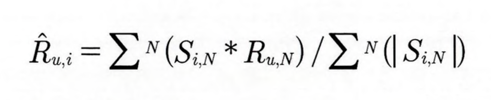

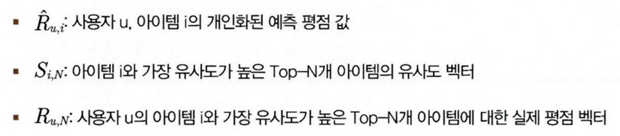

* N값은 아이템의 최근접 이웃 범위 계수를 의미-> 특정 아이템과 유사도가 가장 높은 Top-N개의 다른 아이템을 추출하는데 사용

In [53]:
def predict_rating(ratings_arr, item_sim_arr):
  ratings_pred = ratings_arr.dot(item_sim_arr)/np.array([np.abs(item_sim_arr).sum(axis = 1)])
  return ratings_pred

In [54]:
#예측 평점
ratings_pred = predict_rating(ratings_matrix.values, item_sim_df.values)
ratings_pred_matrix = pd.DataFrame(data=ratings_pred, index = ratings_matrix.index,
                                   columns = ratings_matrix.columns)
ratings_pred_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.070345,0.577855,0.321696,0.227055,0.206958,0.194615,0.249883,0.102542,0.157084,0.178197,...,0.113608,0.181738,0.133962,0.128574,0.006179,0.212070,0.192921,0.136024,0.292955,0.720347
2,0.018260,0.042744,0.018861,0.000000,0.000000,0.035995,0.013413,0.002314,0.032213,0.014863,...,0.015640,0.020855,0.020119,0.015745,0.049983,0.014876,0.021616,0.024528,0.017563,0.000000
3,0.011884,0.030279,0.064437,0.003762,0.003749,0.002722,0.014625,0.002085,0.005666,0.006272,...,0.006923,0.011665,0.011800,0.012225,0.000000,0.008194,0.007017,0.009229,0.010420,0.084501


In [55]:
#실제 평점과의 차이
from sklearn.metrics import mean_squared_error

def get_mse(pred, actual):
  pred = pred[actual.nonzero()].flatten()
  actual = actual[actual.nonzero()].flatten()
  return mean_squared_error(pred, actual)

print('아이템 기반 모든 최근접 이웃 MSE:', get_mse(ratings_pred, ratings_matrix.values))

아이템 기반 모든 최근접 이웃 MSE: 9.895354759094706


In [56]:
def predict_rating_topsim(ratings_arr, item_sim_arr, n = 20):
  pred = np.zeros(ratings_arr.shape)

  for col in range(ratings_arr.shape[1]):
    top_n_items = [np.argsort(item_sim_arr[:, col])[:-n-1:-1]]
    for row in range(ratings_arr.shape[0]):
      pred[row, col] = item_sim_arr[col, :][top_n_items].dot(ratings_arr[row,:][top_n_items].T)
      pred[row, col] /= np.sum(np.abs(item_sim_arr[col, :][top_n_items]))

  return pred

In [57]:
ratings_pred = predict_rating_topsim(ratings_matrix.values, item_sim_df.values, n = 20)
print('아이템 기반 최근접 Top-20 이웃 MSE: ', get_mse(ratings_pred, ratings_matrix.values))

ratings_pred_matrix = pd.DataFrame(data = ratings_pred, index = ratings_matrix.index, columns= ratings_matrix.columns)

아이템 기반 최근접 Top-20 이웃 MSE:  3.694409449382562


In [58]:
user_rating_id = ratings_matrix.loc[9, :]
user_rating_id[user_rating_id >0].sort_values(ascending=False)[:10]

,9
title,
Adaptation (2002),5.0
Austin Powers in Goldmember (2002),5.0
Back to the Future (1985),5.0
Citizen Kane (1941),5.0
"Lord of the Rings: The Fellowship of the Ring, The (2001)",5.0
"Lord of the Rings: The Two Towers, The (2002)",5.0
"Producers, The (1968)",5.0
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981),5.0
Elling (2001),4.0


In [59]:
def get_unseen_movies(ratings_matrix, userId):
  user_rating = ratings_matrix.loc[userId, :]
  already_seen = user_rating[user_rating >0].index.tolist()
  movies_list = ratings_matrix.columns.tolist()
  unseen_list = [movie for movie in movies_list if movie not in already_seen]
  return unseen_list

In [60]:
def recomm_movie_by_userId(pred_df, userId, unseen_list, top_n=10):
  recomm_movies = pred_df.loc[userId, unseen_list].sort_values(ascending = False)[:top_n]
  return recomm_movies

unseen_list = get_unseen_movies(ratings_matrix, 9)

recomm_movies = recomm_movie_by_userId(ratings_pred_matrix, 9, unseen_list, top_n = 10)

recomm_movies = pd.DataFrame(data = recomm_movies.values, index = recomm_movies.index,
                             columns=['pred_score'])
recomm_movies

,pred_score
title,
Shrek (2001),0.866202
Spider-Man (2002),0.857854
"Last Samurai, The (2003)",0.817473
Indiana Jones and the Temple of Doom (1984),0.816626
"Matrix Reloaded, The (2003)",0.800990
Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001),0.765159
Gladiator (2000),0.740956
"Matrix, The (1999)",0.732693
Pirates of the Caribbean: The Curse of the Black Pearl (2003),0.689591


#**07.행렬 분해를 이용한 잠재 요인 협업 필터링 실습**


In [64]:
from sklearn.metrics import mean_squared_error

def get_rmse(R, P, Q, non_zeros):
  error = 0
  full_pred_matrix = np.dot(P, Q.T)

  x_non_zero_ind = [non_zero[0] for non_zero in non_zeros]
  y_non_zero_ind = [non_zero[1] for non_zero in non_zeros]
  R_non_zeros = R[x_non_zero_ind, y_non_zero_ind]
  full_pred_matrix_non_zeros = full_pred_matrix[x_non_zero_ind, y_non_zero_ind]
  mse = mean_squared_error(R_non_zeros, full_pred_matrix_non_zeros)
  rmse = np.sqrt(mse)

In [65]:
def matrix_factorization(R, K, steps = 200, learning_rate= 0.01, r_lambda = 0.01):
  num_users, num_items = R.shape
  np.random.seed(1)

  P = np.random.normal(scale = 1./K, size = (num_users, K))
  Q = np.random.normal(scale = 1./K, size = (num_items, K))

  non_zeros = [(i, j ,R[i,j]) for i in range(num_users) for j in range(num_items) if R[i, j]>0]
  for step in range(steps):
    for i, j, r in non_zeros:
      eij = r-np.dot(P[i, :], Q[j, :].T)
      P[i, :] = P[i,:] + learning_rate*(eij*Q[j, :]-r_lambda*P[i, :])
      Q[j, :] = Q[j,:] + learning_rate*(eij*P[i, :]-r_lambda*Q[j, :])

    rmse = get_rmse(R, P, Q, non_zeros)
    if(step%10) == 0:
      print('### iteration step:', step, "rmse:", rmse)
  return P,Q

In [66]:
import pandas as pd
import numpy as np

movies = pd.read_csv('/content/movies.csv')
ratings = pd.read_csv('/content/ratings.csv')
ratings = ratings[['userId', 'movieId', 'rating']]
ratings_matrix = ratings.pivot_table('rating', index = 'userId', columns = 'movieId')

rating_movies = pd.merge(ratings, movies, on = 'movieId')
ratings_matrix = rating_movies.pivot_table('rating', index = 'userId', columns = 'title')

In [67]:
P, Q = matrix_factorization(ratings_matrix.values, K=50, steps=200, learning_rate=0.01, r_lambda = 0.01)
pred_matrix = np.dot(P, Q.T)

### iteration step: 0 rmse: None
### iteration step: 10 rmse: None
### iteration step: 20 rmse: None
### iteration step: 30 rmse: None
### iteration step: 40 rmse: None
### iteration step: 50 rmse: None
### iteration step: 60 rmse: None
### iteration step: 70 rmse: None
### iteration step: 80 rmse: None
### iteration step: 90 rmse: None
### iteration step: 100 rmse: None
### iteration step: 110 rmse: None
### iteration step: 120 rmse: None
### iteration step: 130 rmse: None
### iteration step: 140 rmse: None
### iteration step: 150 rmse: None
### iteration step: 160 rmse: None
### iteration step: 170 rmse: None
### iteration step: 180 rmse: None
### iteration step: 190 rmse: None


In [68]:
ratings_pred_matrix = pd.DataFrame(data=pred_matrix, index= ratings_matrix.index, columns = ratings_matrix.columns)
ratings_pred_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,3.055084,4.092018,3.564130,4.502167,3.981215,1.271694,3.603274,2.333266,5.091749,3.972454,...,1.402608,4.208382,3.705957,2.720514,2.787331,3.475076,3.253458,2.161087,4.010495,0.859474
2,3.170119,3.657992,3.308707,4.166521,4.311890,1.275469,4.237972,1.900366,3.392859,3.647421,...,0.973811,3.528264,3.361532,2.672535,2.404456,4.232789,2.911602,1.634576,4.135735,0.725684
3,2.307073,1.658853,1.443538,2.208859,2.229486,0.780760,1.997043,0.924908,2.970700,2.551446,...,0.520354,1.709494,2.281596,1.782833,1.635173,1.323276,2.887580,1.042618,2.293890,0.396941


In [69]:
# 사용자가 관람하지 않은 영화명 추출
unseen_list = get_unseen_movies(ratings_matrix, 9)
# 잠재 요인 협업 필터링으로 영화 추천
recomm_movies = recomm_movie_by_userId(ratings_pred_matrix, 9, unseen_list, top_n=10)
# 평점 데이터를 DataFrame으로 생성.
recomm_movies = pd.DataFrame(data=recomm_movies.values, index=recomm_movies.index, columns=['pred_score'])
recomm_movies

,pred_score
title,
Rear Window (1954),5.704612
"South Park: Bigger, Longer and Uncut (1999)",5.451100
Rounders (1998),5.298393
Blade Runner (1982),5.244951
Roger & Me (1989),5.191962
Gattaca (1997),5.183179
Ben-Hur (1959),5.130463
Rosencrantz and Guildenstern Are Dead (1990),5.087375
"Big Lebowski, The (1998)",5.038690


# **08.파이썬 추천 시스템 패키지-Surprise**

In [1]:
import numpy as np

In [3]:
!pip install scikit-surprise

* Surprise에서 데이터 로딩은 Dataset 클래스를 이용해서만 가능.
* Surprise는 무비렌즈 사이트에서 제공하는 과거 버전의 데이터 세트를 가져오는 API를 제공
* Surprise Dataset 클래스의 load_builtin()은 무비렌즈 사이트에서 제공하는 과거 버전
데이터 세트인 ‘ml-10*(10만 개 평점 데이터) 또는 ‘ml-lm’(100만 개 평점 데이터) 데이터를 아카
이브 사이트로부터 내려받아 로컬 디렉터리에 저장한 뒤 데이터를 로딩합니다.

In [4]:
from surprise import SVD
from surprise import Dataset
from surprise import accuracy
from surprise.model_selection import train_test_split

In [5]:
data = Dataset.load_builtin('ml-100k')
#수행 시마다 동일하게 데이터를 분할하기 위해 random_state 값 부여
trainset, testset = train_test_split(data, test_size =.25, random_state=0)

Dataset ml-100k could not be found. Do you want to download it? [Y/n] Y
Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to /root/.surprise_data/ml-100k


* 과거 버전의 데이터 세트. 분리 문자가 \t문자
* 무비렌즈 사이트에서 내려받은 데이터 파일과 동이랗게 로우 레벨의 사용자-아이템 평점 데이터를 그대로 적용 과거 버전의 데이터 세트. 분리 문자가 \t문자
* 무비렌즈 사이트에서 내려받은 데이터 파일과 동이랗게 로우 레벨의 사용자-아이템 평점 데이터를 그대로 적용

In [6]:
algo = SVD(random_state=0)
algo.fit(trainset)

In [7]:
predictions = algo.test(testset)
print('prediction type:', type(predictions), 'size:', len(predictions))
print('prediction 결과의 최초 5개 추출')
predictions[:5]

prediction type: <class 'list'> size: 25000
prediction 결과의 최초 5개 추출


[Prediction(uid='120', iid='282', r_ui=4.0, est=3.5114147666251547, details={'was_impossible': False}),
 Prediction(uid='882', iid='291', r_ui=4.0, est=3.573872419581491, details={'was_impossible': False}),
 Prediction(uid='535', iid='507', r_ui=5.0, est=4.033583485472447, details={'was_impossible': False}),
 Prediction(uid='697', iid='244', r_ui=5.0, est=3.8463639495936905, details={'was_impossible': False}),
 Prediction(uid='751', iid='385', r_ui=4.0, est=3.1807542478219157, details={'was_impossible': False})]

In [8]:
[(pred.uid, pred.iid, pred.est) for pred in predictions[:3]]

[('120', '282', 3.5114147666251547),
 ('882', '291', 3.573872419581491),
 ('535', '507', 4.033583485472447)]

In [9]:
uid = str(196)
iid = str(302)
pred = algo.predict(uid, iid)
print(pred)

user: 196        item: 302        r_ui = None   est = 4.49   {'was_impossible': False}


In [10]:
accuracy.rmse(predictions)

RMSE: 0.9467


0.9466860806937948

**OS 파일 데이터를 Surprise 데이터 세트로 로딩**
* 주의: 로딩되는 데이터 파일에 칼럼명을 가지는 헤더 문자열이 있어서는 안됨. -> ratings.csv 파일은 헤더를 가지고 있음.->to_csv() 함수로 헤더 삭제

In [11]:
import pandas as pd

ratings = pd.read_csv('/content/ratings.csv')
#헤더 제거한 새로운 파일 생성
ratings.to_csv('/content/ratings_noh.csv', index = False, header=False)

* Reader 클래스를 이용해 데이터 파일의 파싱 포맷을 정의
* 4개의 칼럼이 사용자 아이디, 아이템 아이디, 평점, 타임스탬프임을 로딩할 때 알려줘야함

In [12]:
from surprise import Reader

reader = Reader(line_format='user item rating timestamp', sep = ',', rating_scale = (0.5,5))
data = Dataset.load_from_file('/content/ratings_noh.csv', reader=reader)

* Surprise 데이터 세트는 기본적으로 무비렌즈 데이터 형식을 따르므로 무비렌즈 데이터 형식이 아닌
다른 OS 파일의 경우 Reader 클래스를 먼저 설정
**Reader 클래스 주요 파라미터**
* line_format(string): 칼럼을 순서대로 나열. 문자열을 공백으로 분리
* sep(char): 칼럼을 분리하는 분리자. 디폴트: \t. 판다스에서 입력받을 경우 기재 필요X
* rating_scale(tuple, optional): 평점 값의 최소~최대 평점 설저. 디폴트: (1,5)

In [13]:
trainset, testset = train_test_split(data, test_size =.25, random_state=0)

algo = SVD(n_factors = 50, random_state=0)
algo.fit(trainset)
predictions = algo.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8682


0.8681952927143516

** 판다스 DataFrame에서 Surprise 데이터 세트로 로딩**

In [14]:
import pandas as pd
from surprise import Reader, Dataset

ratings = pd.read_csv('/content/ratings.csv')
reader = Reader(rating_scale=(0.5, 5.0))

data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(data, test_size = .25, random_state =0)

algo = SVD(n_factors = 50, random_state=0)
algo.fit(trainset)
predictions = algo.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8682


0.8681952927143516

**교차 검증과 하이퍼 파라미터 튜닝**
* Surprise는 교차 검증과 하이퍼 파라미터 튜닝을 위해 사이킷런과 유사한 cross_validate( )와 GridSearchCV 클래스를 제공

In [15]:
from surprise.model_selection import cross_validate

ratings = pd.read_csv('/content/ratings.csv')
reader = Reader(rating_scale = (0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

algo = SVD(random_state = 0)
cross_validate(algo, data, measures=['RMSE', 'MAE'], cv = 5, verbose= True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8741  0.8766  0.8670  0.8722  0.8729  0.8726  0.0032  
MAE (testset)     0.6716  0.6727  0.6663  0.6686  0.6729  0.6704  0.0026  
Fit time          1.33    1.72    1.25    1.25    1.28    1.37    0.18    
Test time         0.33    0.10    0.21    0.10    0.22    0.19    0.09    


{'test_rmse': array([0.87413994, 0.87656526, 0.86698849, 0.87217666, 0.87291197]),
 'test_mae': array([0.67158723, 0.67271883, 0.66627016, 0.66860324, 0.6728898 ]),
 'fit_time': (1.3310132026672363,
  1.7168080806732178,
  1.25482177734375,
  1.249457836151123,
  1.277155876159668),
 'test_time': (0.3288121223449707,
  0.10231542587280273,
  0.21318769454956055,
  0.0996389389038086,
  0.22016644477844238)}

In [16]:
from surprise.model_selection import GridSearchCV

param_grid = {'n_epochs': [20, 40,60], 'n_factors':[50, 100, 200]}
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
gs.fit(data)

print(gs.best_score['rmse'])
print(gs.best_params['rmse'])

0.877736089495885
{'n_epochs': 20, 'n_factors': 50}


**Surprise를 이용한 개인화 영화 추천 시스템 구축**

In [17]:
#다음 코드는 train_test_split()으로 분리되지 않은 데이터 세트에 fit()을 호출해 오류가 발생
data = Dataset.load_from_df(ratings['userId', 'movieId', 'rating'], reader)
algo = SVD(n_factors = 50, random_state=0)
algo.fit(data)

KeyError: ('userId', 'movieId', 'rating')

In [18]:
from surprise.dataset import DatasetAutoFolds

reader = Reader(line_format='user item rating timestamp', sep = ',', rating_scale = (0.5,5))

data_folds = DatasetAutoFolds(ratings_file = '/content/ratings_noh.csv', reader = reader)

trainset = data_folds.build_full_trainset()

In [19]:
algo = SVD(n_epochs=20, n_factors = 50, random_state=0)
algo.fit(trainset)

In [20]:
movies = pd.read_csv('/content/movies.csv')

movieIds = ratings[ratings['userId'] == 9]['movieId']

if movieIds[movieIds==42].count() ==0:
  print('사용자 아이디 9는 영화 아이디 42의 평점 없음')

print(movies[movies['movieId']==42])

사용자 아이디 9는 영화 아이디 42의 평점 없음
    movieId                   title              genres
38       42  Dead Presidents (1995)  Action|Crime|Drama


In [21]:
uid = str(9)
iid = str(42)

pred = algo.predict(uid, iid, verbose=True)

user: 9          item: 42         r_ui = None   est = 3.13   {'was_impossible': False}


In [22]:
def get_unseen_surprise(ratings, movies, userId):
  seen_movies = ratings[ratings['userId']==userId]['movieId'].tolist()
  total_movies = movies['movieId'].tolist()

  unseen_movies = [movie for movie in total_movies if movie not in movies]
  print('평점 매긴 영화 수:', len(seen_movies), '추천 대상 영화 수:', len(unseen_movies),
        '전체 영화 수:', len(total_movies))
  return unseen_movies

unseen_movies = get_unseen_surprise(ratings, movies, 9)

평점 매긴 영화 수: 46 추천 대상 영화 수: 9742 전체 영화 수: 9742


In [23]:
def recomm_movie_by_surprise(algo, userId, unseen_movies, top_n=10):
  predictions = [algo.predict(str(userId), str(movieId)) for movieId in unseen_movies]

  def sortkey_est(pred):
    return pred.est
  predictions.sort(key=sortkey_est, reverse=True)
  top_predictions = predictions[:top_n]

  top_movie_ids = [int(pred.iid) for pred in top_predictions]
  top_movie_rating = [pred.est for pred in top_predictions]
  top_movie_titles = movies[movies.movieId.isin(top_movie_ids)]['title']
  top_movie_preds = [(id, title, rating) for id, title, rating in zip(top_movie_ids, top_movie_titles, top_movie_rating)]

  return top_movie_preds

unseen_movies = get_unseen_surprise(ratings, movies, 9)
top_movie_preds = recomm_movie_by_surprise(algo, 9, unseen_movies, top_n=10)

print('#### Top-10 추천 영화 리스트 ####')
for top_movie in top_movie_preds:
  print(top_movie[1], ":", top_movie[2])

평점 매긴 영화 수: 46 추천 대상 영화 수: 9742 전체 영화 수: 9742
#### Top-10 추천 영화 리스트 ####
Usual Suspects, The (1995) : 4.306302135700814
Star Wars: Episode IV - A New Hope (1977) : 4.281663842987387
Pulp Fiction (1994) : 4.278152632122759
Godfather, The (1972) : 4.226073566460876
Streetcar Named Desire, A (1951) : 4.205267497432363
Star Wars: Episode V - The Empire Strikes Back (1980) : 4.1918097904381995
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981) : 4.154746591122657
Star Wars: Episode VI - Return of the Jedi (1983) : 4.122016128534504
Goodfellas (1990) : 4.118002684813024
Lord of the Rings: The Fellowship of the Ring, The (2001) : 4.108009609093436
